In [ ]:
import os
import numpy as np
import pandas as pd
import random
import gc
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, precision_recall_curve, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dense, Activation, ZeroPadding1D,
    GlobalAveragePooling1D, Add, Concatenate, Dropout, BatchNormalization, Input, Lambda)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

random.seed(20)
np.random.seed(20)
tf.random.set_seed(20)
tf.config.optimizer.set_jit(False)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')


2026-06-14 14:34:45.327812: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781447685.486478      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781447685.530731      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781447685.908712      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781447685.908757      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781447685.908760      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
config = {
    "monitored_dir": "/kaggle/input/datasets/lampdp/masque-300-web",
    "unmonitored_dir": "/kaggle/input/datasets/lampdp/masque-open-world",
    "closedworld_checkpoint": "/kaggle/input/datasets/lampdp/res-deepmasque/checkpoints/latest.weights.h5",

    "batch_size": 50,
    "seq_length": 5000,

    "dir_dilations": True,
    "time_dilations": True,
    "size_dilations": True,
    "inter_time": True,
    "scale_metadata": True,
    "test_size": 0.1,

    "features_to_use": ["dir", "time", "size", "metadata"],

    "use_feature_selection": True,
    "num_selected_metadata": 9,

    "num_monitored": 300,
    "unmon_train_ratio": 0.5,   # giu nguyen split de so sanh, nhung KHONG dung unmon_train de train
}

print('Open-World VarCNN+SupCon (Nearest-Centroid, no retraining) Setup:')
print(f'  Monitored:         {config["num_monitored"]} websites')
print(f'  Closed-world ckpt: {config["closedworld_checkpoint"]}')
print('  Khong fine-tune, khong train lai - chi load weight + tinh centroid + danh gia')


Open-World VarCNN+SupCon (Nearest-Centroid, no retraining) Setup:
  Monitored:         300 websites
  Closed-world ckpt: /kaggle/input/datasets/lampdp/res-deepmasque/checkpoints/latest.weights.h5
  Khong fine-tune, khong train lai - chi load weight + tinh centroid + danh gia


In [ ]:
def load_csv_folder(data_dir, seq_length, max_classes=None):
    all_data = {}
    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    if max_classes: classes = classes[:max_classes]
    for label_name in tqdm(classes, desc=f"Loading {os.path.basename(data_dir)}"):
        class_dir = os.path.join(data_dir, label_name)
        files = [f for f in os.listdir(class_dir) if f.endswith('.csv')]
        samples = []
        for file in files:
            try: df = pd.read_csv(os.path.join(class_dir, file), sep=';')
            except: continue
            if len(df) == 0: continue
            dirs = np.where(df['direction'].values == 0, -1, 1)
            times = df['relative_time'].values; lengths = df['length'].values
            dir_seq = np.zeros(seq_length, dtype=np.int8)
            time_seq = np.zeros(seq_length, dtype=np.float32)
            size_seq = np.zeros(seq_length, dtype=np.float32)
            limit = min(len(dirs), seq_length)
            dir_seq[:limit] = dirs[:limit]; time_seq[:limit] = times[:limit]; size_seq[:limit] = lengths[:limit]
            in_mask, out_mask = (dirs==-1), (dirs==1)
            ti, to_ = np.sum(in_mask), np.sum(out_mask); tp = ti+to_; tt = times[-1] if tp>0 else 0.0
            if tp == 0: meta = np.zeros(13, dtype=np.float32)
            else:
                msi = np.mean(lengths[in_mask]) if ti>0 else 0.0; mso = np.mean(lengths[out_mask]) if to_>0 else 0.0
                mst = np.mean(lengths) if tp>0 else 0.0
                ri = msi/mst if mst>0 else 0.0; ro = mso/mst if mst>0 else 0.0
                tin, tout = times[in_mask], times[out_mask]
                mti = np.mean(np.diff(tin)) if len(tin)>1 else 0.0; mto = np.mean(np.diff(tout)) if len(tout)>1 else 0.0
                meta = np.array([tp,ti,to_,ti/tp,to_/tp,tt,tt/tp,mso,msi,ri,ro,mti,mto], dtype=np.float32)
            samples.append((dir_seq, time_seq, size_seq, meta))
        if samples: all_data[label_name] = samples
    return all_data


def build_arrays(data_dict, label_map):
    dirs, times, sizes, metas, labels = [], [], [], [], []
    for cls_name, samples in data_dict.items():
        lbl = label_map[cls_name]
        for d, t, s, m in samples:
            dirs.append(d); times.append(t); sizes.append(s); metas.append(m); labels.append(lbl)
    return dirs, times, sizes, metas, labels


def to_input_arrays(d, t, s, m, config):
    dir_arr = np.expand_dims(np.array(d), -1)
    time_arr = np.array(t)
    if config['inter_time']:
        inter = np.zeros_like(time_arr); inter[:, 1:] = time_arr[:, 1:] - time_arr[:, :-1]; time_arr = inter
    time_arr = np.expand_dims(time_arr, -1)
    size_arr = np.expand_dims(np.array(s) / 1500.0, -1)
    meta_arr = np.array(m)
    return dir_arr, time_arr, size_arr, meta_arr


seq_length = config['seq_length']

# 1. Load MONITORED (300 web)
print('Loading MONITORED (300 web)...')
mon_data = load_csv_folder(config['monitored_dir'], seq_length)
mon_classes = sorted(mon_data.keys())
print(f'  {len(mon_classes)} classes, {sum(len(v) for v in mon_data.values())} traces')

le = LabelEncoder(); le.fit(mon_classes)
mon_label_map = {cls: le.transform([cls])[0] for cls in mon_classes}
unmon_label = len(mon_classes)   # 300
num_classes = unmon_label + 1    # 301 (chi de tham chieu)

d1, t1, s1, m1, l1 = build_arrays(mon_data, mon_label_map)
dir_arr, time_arr, size_arr, meta_arr = to_input_arrays(d1, t1, s1, m1, config)
label_arr = np.array(l1)

# 2. Train/test split (chi monitored) - train -> centroid, test -> eval
X_dir_train, X_dir_test, X_time_train, X_time_test, X_size_train, X_size_test, \
X_meta_train, X_meta_test, y_train_lbl, y_test_lbl = train_test_split(
    dir_arr, time_arr, size_arr, meta_arr, label_arr,
    test_size=config['test_size'], random_state=42, stratify=label_arr)

print(f'Monitored train (centroid pool): {len(y_train_lbl)}')
print(f'Monitored test  (eval):          {len(y_test_lbl)}')

# 3. Scale metadata + feature selection (fit tren train, transform test)
if config['scale_metadata']:
    scaler = StandardScaler()
    X_meta_train = scaler.fit_transform(X_meta_train)
    X_meta_test = scaler.transform(X_meta_test)

if config['use_feature_selection']:
    k = config['num_selected_metadata']
    selector = SelectKBest(score_func=f_classif, k=k)
    X_meta_train = selector.fit_transform(X_meta_train, y_train_lbl)
    X_meta_test = selector.transform(X_meta_test)

meta_dim = X_meta_train.shape[1]
print(f'meta_dim = {meta_dim}')

# 4. Load UNMONITORED (6000 web) - khong dung de train, chi de eval (unseen half)
print('\nLoading UNMONITORED (6000 web)...')
unmon_data = load_csv_folder(config['unmonitored_dir'], seq_length)
unmon_classes = sorted(unmon_data.keys())
print(f'  {len(unmon_classes)} classes, {sum(len(v) for v in unmon_data.values())} traces')

np.random.seed(42)
unmon_shuffled = list(unmon_classes)
np.random.shuffle(unmon_shuffled)
split = int(len(unmon_shuffled) * config['unmon_train_ratio'])
unmon_eval_cls = unmon_shuffled[split:]   # unseen half

unmon_eval_data = {k: unmon_data[k] for k in unmon_eval_cls}
unmon_eval_map = {k: -1 for k in unmon_eval_cls}  # label khong quan trong
d4, t4, s4, m4, _ = build_arrays(unmon_eval_data, unmon_eval_map)
ut_dir, ut_time, ut_size, ut_meta = to_input_arrays(d4, t4, s4, m4, config)

if config['scale_metadata']:
    ut_meta = scaler.transform(ut_meta)
if config['use_feature_selection']:
    ut_meta = selector.transform(ut_meta)

print(f'Unmonitored eval (unseen): {ut_dir.shape[0]} traces tu {len(unmon_eval_cls)} websites')


Loading MONITORED (300 web)...


Loading masque-300-web:   0%|          | 0/300 [00:00<?, ?it/s]

  300 classes, 148344 traces
Monitored train (centroid pool): 133509
Monitored test  (eval):          14835
meta_dim = 9

Loading UNMONITORED (6000 web)...


Loading masque-open-world:   0%|          | 0/6000 [00:00<?, ?it/s]

  6000 classes, 60044 traces
Unmonitored eval (unseen): 30015 traces tu 3000 websites


In [ ]:
# =========================================================
# VAR-CNN + SUPCON ARCHITECTURE (300 classes)
# Dual output: class_output (softmax) + emb_output (128-dim, l2-normalized)
# =========================================================
parameters = {'kernel_initializer': 'he_normal'}

def dilated_basic_1d(filters, suffix, stage=0, block=0, kernel_size=3, numerical_name=False, stride=None, dilations=(1, 1)):
    if stride is None:
        stride = 1 if block != 0 or stage == 0 else 2
    block_char = f'b{block}' if block > 0 and numerical_name else chr(ord('a') + block)
    stage_char = str(stage + 2)

    def f(x):
        y = Conv1D(filters, kernel_size, padding='causal', strides=stride, dilation_rate=dilations[0], use_bias=False, name=f'res{stage_char}{block_char}_branch2a_{suffix}', **parameters)(x)
        y = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch2a_{suffix}')(y)
        y = Activation('relu', name=f'res{stage_char}{block_char}_branch2a_relu_{suffix}')(y)

        y = Conv1D(filters, kernel_size, padding='causal', use_bias=False, dilation_rate=dilations[1], name=f'res{stage_char}{block_char}_branch2b_{suffix}', **parameters)(y)
        y = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch2b_{suffix}')(y)

        if block == 0:
            shortcut = Conv1D(filters, 1, strides=stride, use_bias=False, name=f'res{stage_char}{block_char}_branch1_{suffix}', **parameters)(x)
            shortcut = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch1_{suffix}')(shortcut)
        else:
            shortcut = x

        y = Add(name=f'res{stage_char}{block_char}_{suffix}')([y, shortcut])
        y = Activation('relu', name=f'res{stage_char}{block_char}_relu_{suffix}')(y)
        return y
    return f

def basic_1d(filters, suffix, stage=0, block=0, kernel_size=3, numerical_name=False, stride=None, dilations=(1, 1)):
    if stride is None:
        stride = 1 if block != 0 or stage == 0 else 2
    dilations = (1, 1)
    block_char = f'b{block}' if block > 0 and numerical_name else chr(ord('a') + block)
    stage_char = str(stage + 2)

    def f(x):
        y = Conv1D(filters, kernel_size, padding='same', strides=stride, dilation_rate=dilations[0], use_bias=False, name=f'res{stage_char}{block_char}_branch2a_{suffix}', **parameters)(x)
        y = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch2a_{suffix}')(y)
        y = Activation('relu', name=f'res{stage_char}{block_char}_branch2a_relu_{suffix}')(y)

        y = Conv1D(filters, kernel_size, padding='same', use_bias=False, dilation_rate=dilations[1], name=f'res{stage_char}{block_char}_branch2b_{suffix}', **parameters)(y)
        y = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch2b_{suffix}')(y)

        if block == 0:
            shortcut = Conv1D(filters, 1, strides=stride, use_bias=False, name=f'res{stage_char}{block_char}_branch1_{suffix}', **parameters)(x)
            shortcut = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch1_{suffix}')(shortcut)
        else:
            shortcut = x

        y = Add(name=f'res{stage_char}{block_char}_{suffix}')([y, shortcut])
        y = Activation('relu', name=f'res{stage_char}{block_char}_relu_{suffix}')(y)
        return y
    return f

def ResNet18(inputs, suffix, blocks=[2, 2, 2, 2], block=dilated_basic_1d, numerical_names=[True]*4):
    x = ZeroPadding1D(padding=3, name=f'padding_conv1_{suffix}')(inputs)
    x = Conv1D(64, 7, strides=2, use_bias=False, name=f'conv1_{suffix}')(x)
    x = BatchNormalization(epsilon=1e-5, name=f'bn_conv1_{suffix}')(x)
    x = Activation('relu', name=f'conv1_relu_{suffix}')(x)
    x = MaxPooling1D(3, strides=2, padding='same', name=f'pool1_{suffix}')(x)

    features = 64
    for stage_id, iterations in enumerate(blocks):
        x = block(features, suffix, stage_id, 0, dilations=(1, 2), numerical_name=False)(x)
        for block_id in range(1, iterations):
            x = block(features, suffix, stage_id, block_id, dilations=(4, 8), numerical_name=(block_id > 0 and numerical_names[stage_id]))(x)
        features *= 2

    x = GlobalAveragePooling1D(name=f'pool5_{suffix}')(x)
    return x


def build_varcnn_supcon(config, num_classes, meta_dim):
    seq_length = config['seq_length']
    features = config['features_to_use']

    input_params = []
    concat_params = []

    if 'dir' in features:
        dir_input = Input(shape=(seq_length, 1,), name='dir_input')
        dir_block = dilated_basic_1d if config['dir_dilations'] else basic_1d
        dir_output = ResNet18(dir_input, 'dir', block=dir_block)
        input_params.append(dir_input)
        concat_params.append(dir_output)

    if 'time' in features:
        time_input = Input(shape=(seq_length, 1,), name='time_input')
        time_block = dilated_basic_1d if config['time_dilations'] else basic_1d
        time_output = ResNet18(time_input, 'time', block=time_block)
        input_params.append(time_input)
        concat_params.append(time_output)

    if 'size' in features:
        size_input = Input(shape=(seq_length, 1,), name='size_input')
        size_block = dilated_basic_1d if config.get('size_dilations', True) else basic_1d
        size_output = ResNet18(size_input, 'size', block=size_block)
        input_params.append(size_input)
        concat_params.append(size_output)

    if 'metadata' in features:
        metadata_input = Input(shape=(meta_dim,), name='metadata_input')
        metadata_output = Dense(32)(metadata_input)
        metadata_output = BatchNormalization()(metadata_output)
        metadata_output = Activation('relu')(metadata_output)
        input_params.append(metadata_input)
        concat_params.append(metadata_output)

    if len(concat_params) == 1:
        combined = concat_params[0]
    else:
        combined = Concatenate()(concat_params)

    # Head 1: Classification (KHONG dung trong danh gia nay)
    fc = Dense(1024, name='fc1')(combined)
    fc = BatchNormalization(name='fc1_bn')(fc)
    fc = Activation('relu', name='fc1_relu')(fc)
    fc = Dropout(0.6, name='fc1_drop')(fc)
    class_output = Dense(num_classes, activation='softmax', name='class_output')(fc)

    # Head 2: Embedding 128-dim (dung de tinh centroid + cosine)
    emb = Dense(128, name='emb_proj')(combined)
    emb_output = Lambda(lambda x: tf.math.l2_normalize(x, axis=1), name='emb_output')(emb)

    model = Model(inputs=input_params, outputs=[class_output, emb_output])
    return model


In [5]:
# =========================================================
# LOAD CLOSED-WORLD CHECKPOINT (300 web) - KHONG TRAIN LAI
# =========================================================
import gc as _gc
tf.keras.backend.clear_session(); gc.collect()

model = build_varcnn_supcon(config, num_classes=config['num_monitored'], meta_dim=meta_dim)
print(f'Model built: {model.count_params():,} params, {config["num_monitored"]} classes')

model.load_weights(config['closedworld_checkpoint'])
print(f'Loaded closed-world checkpoint: {config["closedworld_checkpoint"]}')
print('class_output van ton tai trong model nhung KHONG duoc dung de danh gia.')
print('Embedding lay tu nhanh emb_output (128-dim, l2-normalized).')


def get_inputs(X_dir, X_time, X_size, X_meta, features):
    inputs = {}
    if 'dir' in features: inputs['dir_input'] = X_dir
    if 'time' in features: inputs['time_input'] = X_time
    if 'size' in features: inputs['size_input'] = X_size
    if 'metadata' in features: inputs['metadata_input'] = X_meta
    return inputs


def get_embeddings(inputs, batch_size):
    """model.predict tra ve [class_output, emb_output] - chi lay emb_output."""
    _, emb = model.predict(inputs, batch_size=batch_size)
    return emb

def get_embeddings(X_dir, X_time, X_size, X_meta, features, batch_size=32, desc='Embeddings'):
    """Predict theo batch nho, tranh OOM khi data lon. Tra ve chi emb_output (128-dim)."""
    n = len(X_dir)
    out = []
    for i in tqdm(range(0, n, batch_size), desc=desc):
        sl = slice(i, i + batch_size)
        batch_inputs = get_inputs(X_dir[sl], X_time[sl], X_size[sl], X_meta[sl], features)
        _, emb = model.predict(batch_inputs, batch_size=batch_size, verbose=0)
        out.append(emb)
        if i % (batch_size * 20) == 0:
            _gc.collect()
    return np.concatenate(out, axis=0)

I0000 00:00:1781451321.199916      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781451321.207159      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model built: 13,693,100 params, 300 classes
Loaded closed-world checkpoint: /kaggle/input/datasets/lampdp/res-deepmasque/checkpoints/latest.weights.h5
class_output van ton tai trong model nhung KHONG duoc dung de danh gia.
Embedding lay tu nhanh emb_output (128-dim, l2-normalized).


In [6]:
# =========================================================
# TINH CENTROID TU TAP TRAIN CUA 300-WEB (closed-world)
# =========================================================
train_emb = get_embeddings(X_dir_train, X_time_train, X_size_train, X_meta_train,
                            config['features_to_use'], batch_size=32, desc='Train emb')

centroids = []
for c in range(config['num_monitored']):
    mask = y_train_lbl == c
    if np.sum(mask) > 0:
        cent = np.mean(train_emb[mask], axis=0)
        cent = cent / (np.linalg.norm(cent) + 1e-8)
        centroids.append(cent)
    else:
        centroids.append(np.zeros(train_emb.shape[1]))
centroids = np.array(centroids)

del train_emb
gc.collect()
print(f'{len(centroids)} centroids computed (dim={centroids.shape[1]})')

Train emb:   0%|          | 0/4173 [00:00<?, ?it/s]

I0000 00:00:1781451327.405371      71 service.cc:152] XLA service 0x787804002c10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781451327.405404      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781451327.405413      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781451328.427195      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-14 15:35:30.812716: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv %cudnn-conv.73 = (f32[256,128,1,79]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,128,1,81]{3,2,1,0} %bitcast.8520, f32[128,128,1,3]{3,2,1,0} %bitcast.8524), window={size=1x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_type="Conv2D" op_name="functional_1/res3b1_branch2b_dir_1/convolution" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/p

300 centroids computed (dim=128)


In [7]:
# =========================================================
# FORWARD OPEN-WORLD DATA QUA ENCODER (1 lan, khong train lai)
# Test set = monitored test (closed-world) + unmonitored unseen
# =========================================================
emb_mon_test = get_embeddings(X_dir_test, X_time_test, X_size_test, X_meta_test,
                               config['features_to_use'], batch_size=32, desc='Mon test emb')
emb_unmon = get_embeddings(ut_dir, ut_time, ut_size, ut_meta,
                            config['features_to_use'], batch_size=32, desc='Unmon emb')


def cos_dist_and_pred(emb, centroids):
    # emb da duoc l2-normalize boi model (Lambda l2_normalize), nhung normalize lai cho an toan
    emb_norm = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8)
    sim = emb_norm @ centroids.T
    max_sim = np.max(sim, axis=1)
    nearest = np.argmax(sim, axis=1)
    cos_dist = 1 - max_sim
    return cos_dist, nearest

cos_dist_mon, nearest_mon = cos_dist_and_pred(emb_mon_test, centroids)
cos_dist_unmon, nearest_unmon = cos_dist_and_pred(emb_unmon, centroids)

all_cos_dist = np.concatenate([cos_dist_mon, cos_dist_unmon])
all_nearest = np.concatenate([nearest_mon, nearest_unmon])
y_true_bin = np.concatenate([np.zeros(len(cos_dist_mon)), np.ones(len(cos_dist_unmon))]).astype(int)
y_true_mon_classes = y_test_lbl

del emb_mon_test, emb_unmon
gc.collect()

print(f'Test: {len(cos_dist_mon)} monitored + {len(cos_dist_unmon)} unmonitored = {len(all_cos_dist)} total')


Mon test emb:   0%|          | 0/464 [00:00<?, ?it/s]

Unmon emb:   0%|          | 0/938 [00:00<?, ?it/s]

2026-06-14 15:47:51.399574: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv %cudnn-conv.73 = (f32[248,128,1,79]{3,2,1,0}, u8[0]{0}) custom-call(f32[248,128,1,81]{3,2,1,0} %bitcast.8520, f32[128,128,1,3]{3,2,1,0} %bitcast.8524), window={size=1x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_type="Conv2D" op_name="functional_1/res3b1_branch2b_dir_1/convolution" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-06-14 15:47:54.720426: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.320982605s
Trying algorithm eng3{k11=2} for conv %cudnn-conv.73 = (f32[248,128,1,79]{

Test: 14835 monitored + 30015 unmonitored = 44850 total


OPEN-WORLD DETECTION (Nearest-Centroid Distance, emb_output)
Threshold (cos_dist >= t -> unmonitored): t = 0.1531
TP=27923, FP=2021, TN=12814, FN=2092
Accuracy:  0.9083
Recall:    0.9303  (27923/30015 unmon detected)
Precision: 0.9325
F1:        0.9314
AUC-ROC:   0.9619

CLOSED-WORLD ACCURACY (nearest-centroid, 300 classes)
Nearest-centroid accuracy (chi mon test, bo qua threshold): 0.9818

OVERALL 301-WAY ACCURACY (nearest-centroid + threshold)
Overall accuracy: 0.9071


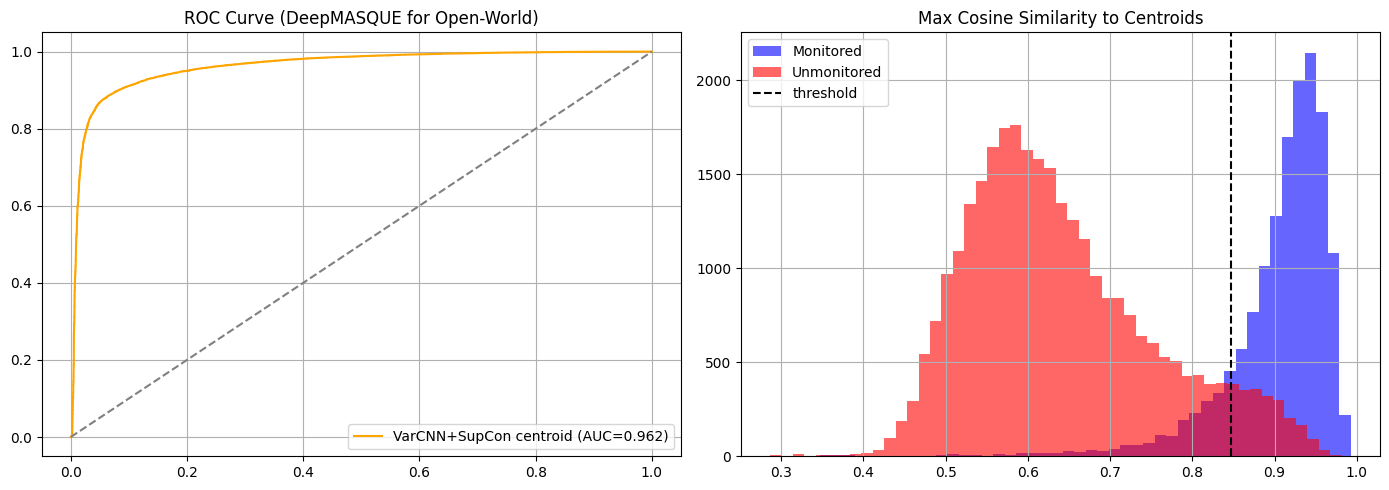


SUMMARY - VarCNN+SupCon Nearest-Centroid Open-World
Metric                              Value     
---------------------------------------------
Open-world Accuracy                 0.9083    
Open-world Recall                   0.9303    
Open-world Precision                0.9325    
Open-world F1                       0.9314    
Open-world AUC                      0.9619    
Closed-world Acc (nearest-centroid) 0.9818    
Overall 301-way Acc                 0.9071    

Done!


In [8]:
# =========================================================
# TIM THRESHOLD (toi uu F1 cho bai toan binary mon/unmon)
# =========================================================
prec, rec, thr = precision_recall_curve(y_true_bin, all_cos_dist)
f1 = 2 * prec * rec / (prec + rec + 1e-8)
best_idx = np.argmax(f1)
THRESHOLD = thr[best_idx] if best_idx < len(thr) else 0.5

pred_bin = (all_cos_dist >= THRESHOLD).astype(int)
tp = np.sum((pred_bin==1)&(y_true_bin==1))
fp = np.sum((pred_bin==1)&(y_true_bin==0))
tn = np.sum((pred_bin==0)&(y_true_bin==0))
fn = np.sum((pred_bin==0)&(y_true_bin==1))

acc_bin = (tp+tn)/len(y_true_bin)
tpr = tp/(tp+fn) if (tp+fn)>0 else 0
fpr = fp/(fp+tn) if (fp+tn)>0 else 0
prec_bin = tp/(tp+fp) if (tp+fp)>0 else 0
try:
    auc = roc_auc_score(y_true_bin, all_cos_dist)
except:
    auc = 0

print('='*60)
print('OPEN-WORLD DETECTION (Nearest-Centroid Distance, emb_output)')
print('='*60)
print(f'Threshold (cos_dist >= t -> unmonitored): t = {THRESHOLD:.4f}')
print(f'TP={tp}, FP={fp}, TN={tn}, FN={fn}')
print(f'Accuracy:  {acc_bin:.4f}')
print(f'Recall:    {tpr:.4f}  ({tp}/{tp+fn} unmon detected)')
print(f'Precision: {prec_bin:.4f}')
print(f'F1:        {f1[best_idx]:.4f}')
print(f'AUC-ROC:   {auc:.4f}')

# =========================================================
# CLOSED-WORLD CLASSIFICATION (Nearest-Centroid, KHONG dung softmax)
# =========================================================
nearest_mon_pred = all_nearest[:len(cos_dist_mon)]
cw_acc_nearest = accuracy_score(y_true_mon_classes, nearest_mon_pred)
print('\n' + '='*60)
print('CLOSED-WORLD ACCURACY (nearest-centroid, 300 classes)')
print('='*60)
print(f'Nearest-centroid accuracy (chi mon test, bo qua threshold): {cw_acc_nearest:.4f}')

# =========================================================
# OVERALL 301-WAY: ket hop ca 2 buoc quyet dinh
#   pred = unmonitored (300) neu cos_dist >= threshold
#   pred = nearest centroid (0..299) neu cos_dist < threshold
# =========================================================
final_pred = np.where(pred_bin == 1, unmon_label, all_nearest)
y_true_full = np.concatenate([y_true_mon_classes, np.full(len(cos_dist_unmon), unmon_label)])
overall_acc = accuracy_score(y_true_full, final_pred)

print('\n' + '='*60)
print('OVERALL 301-WAY ACCURACY (nearest-centroid + threshold)')
print('='*60)
print(f'Overall accuracy: {overall_acc:.4f}')

# =========================================================
# PLOTS
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

try:
    fpr_arr, tpr_arr, _ = roc_curve(y_true_bin, all_cos_dist)
    axes[0].plot(fpr_arr, tpr_arr, color='orange', label=f'VarCNN+SupCon centroid (AUC={auc:.3f})')
    axes[0].plot([0,1],[0,1],'--',color='gray')
    axes[0].set_title('ROC Curve (DeepMASQUE for Open-World)'); axes[0].legend(); axes[0].grid(True)
except: pass

axes[1].hist(1 - cos_dist_mon, bins=50, alpha=0.6, label='Monitored', color='blue')
axes[1].hist(1 - cos_dist_unmon, bins=50, alpha=0.6, label='Unmonitored', color='red')
axes[1].axvline(1 - THRESHOLD, color='black', linestyle='--', label='threshold')
axes[1].set_title('Max Cosine Similarity to Centroids'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.savefig('varcnn_supcon_centroid_openworld.png', dpi=150); plt.show()

# =========================================================
# SUMMARY
# =========================================================
print('\n' + '='*60)
print('SUMMARY - VarCNN+SupCon Nearest-Centroid Open-World')
print('='*60)
print(f'{"Metric":<35} {"Value":<10}')
print('-'*45)
print(f'{"Open-world Accuracy":<35} {acc_bin:<10.4f}')
print(f'{"Open-world Recall":<35} {tpr:<10.4f}')
print(f'{"Open-world Precision":<35} {prec_bin:<10.4f}')
print(f'{"Open-world F1":<35} {f1[best_idx]:<10.4f}')
print(f'{"Open-world AUC":<35} {auc:<10.4f}')
print(f'{"Closed-world Acc (nearest-centroid)":<35} {cw_acc_nearest:<10.4f}')
print(f'{"Overall 301-way Acc":<35} {overall_acc:<10.4f}')
print('\nDone!')
